In [1]:
# ============================================================
# CELL 1 — ENVIRONMENT + CONFIGURATION
# AI-Powered Misinformation Detection System
# ============================================================

!pip -q install transformers datasets accelerate joblib shap seaborn

import os
import re
import json
import random
import warnings
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from sklearn.pipeline import Pipeline

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

warnings.filterwarnings("ignore")

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -----------------------------
# Configuration
# -----------------------------
CONFIG = {
    "seed": SEED,

    # Data
    "text_columns": ["title", "text"],
    "label_column": "label",
    "subject_column": "subject",
    "date_column": "date",

    # Split
    "test_size": 0.15,
    "validation_size": 0.15,

    # TF-IDF
    "max_features": 50_000,
    "min_df": 2,
    "max_df": 0.95,
    "ngram_range": (1, 2),
    "sublinear_tf": True,

    # Logistic Regression
    "logistic_C": 2.0,

    # Naive Bayes
    "nb_alpha": 0.1,

    # Transformer
    "transformer_name": "distilbert-base-uncased",
    "max_length": 256,
    "transformer_epochs": 2,
    "transformer_batch_size": 8,

    # Threshold
    "threshold_grid": np.round(np.arange(0.30, 0.751, 0.01), 2),

    # Output
    "output_dir": "/content/misinformation_project"
}

OUTPUT_DIR = Path(CONFIG["output_dir"])
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {DEVICE}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Random seed: {SEED}")


# ============================================================
# Helper Functions
# ============================================================

def clean_text(text):
    """Basic deterministic text normalization."""
    if pd.isna(text):
        return ""

    text = str(text)
    text = text.replace("\n", " ")
    text = text.replace("\r", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def build_model_text(df, title_col="title", text_col="text"):
    """Combine title and article body without using subject."""
    title = df[title_col].fillna("").astype(str)
    body = df[text_col].fillna("").astype(str)

    return (title + " " + body).str.replace(
        r"\s+", " ", regex=True
    ).str.strip()


def evaluate_predictions(y_true, y_pred, y_prob=None):
    """Return compact classification metrics."""
    result = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }

    if y_prob is not None:
        result["ROC-AUC"] = roc_auc_score(y_true, y_prob)
        result["PR-AUC"] = average_precision_score(y_true, y_prob)
    else:
        result["ROC-AUC"] = np.nan
        result["PR-AUC"] = np.nan

    return result


def threshold_search(y_true, probabilities, thresholds):
    """Optimize threshold on validation data only."""
    rows = []

    for threshold in thresholds:
        predictions = (probabilities >= threshold).astype(int)

        rows.append({
            "threshold": threshold,
            "precision": precision_score(
                y_true, predictions, zero_division=0
            ),
            "recall": recall_score(
                y_true, predictions, zero_division=0
            ),
            "f1": f1_score(
                y_true, predictions, zero_division=0
            )
        })

    result = pd.DataFrame(rows)
    best = result.loc[result["f1"].idxmax()]

    return result, float(best["threshold"])


def artifact_clean_text(text):
    """
    Remove common publisher/source/style artifacts.
    This is an experimental transformation only.
    """
    text = clean_text(text)

    patterns = [
        r"\breuters\b",
        r"\bwashington reuters\b",
        r"\bvia\b",
        r"\bread more\b",
        r"\bfeatured image\b",
        r"\bimage\b",
        r"\bsource\s*:",
        r"\bpublisher\s*:"
    ]

    for pattern in patterns:
        text = re.sub(pattern, " ", text, flags=re.IGNORECASE)

    text = re.sub(r"\s+", " ", text)
    return text.strip()


def print_section(title):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)

Device: cuda
CUDA available: True
Output directory: /content/misinformation_project
Random seed: 42



UPLOAD DATASET


Saving Fake.csv to Fake.csv
Saving True.csv to True.csv
Raw Fake.csv: 23,481
Raw True.csv: 21,417
Combined dataset: 44,898

Rows before cleaning: 44,898
Rows after cleaning:  39,100
Removed rows:         5,798


,Metric,Value
0,Total articles,39100.00
1,Real articles,21195.00
2,Fake articles,17905.00
3,Real %,54.21
4,Fake %,45.79
5,Unique subjects,7.00
6,Valid dates,31815.00


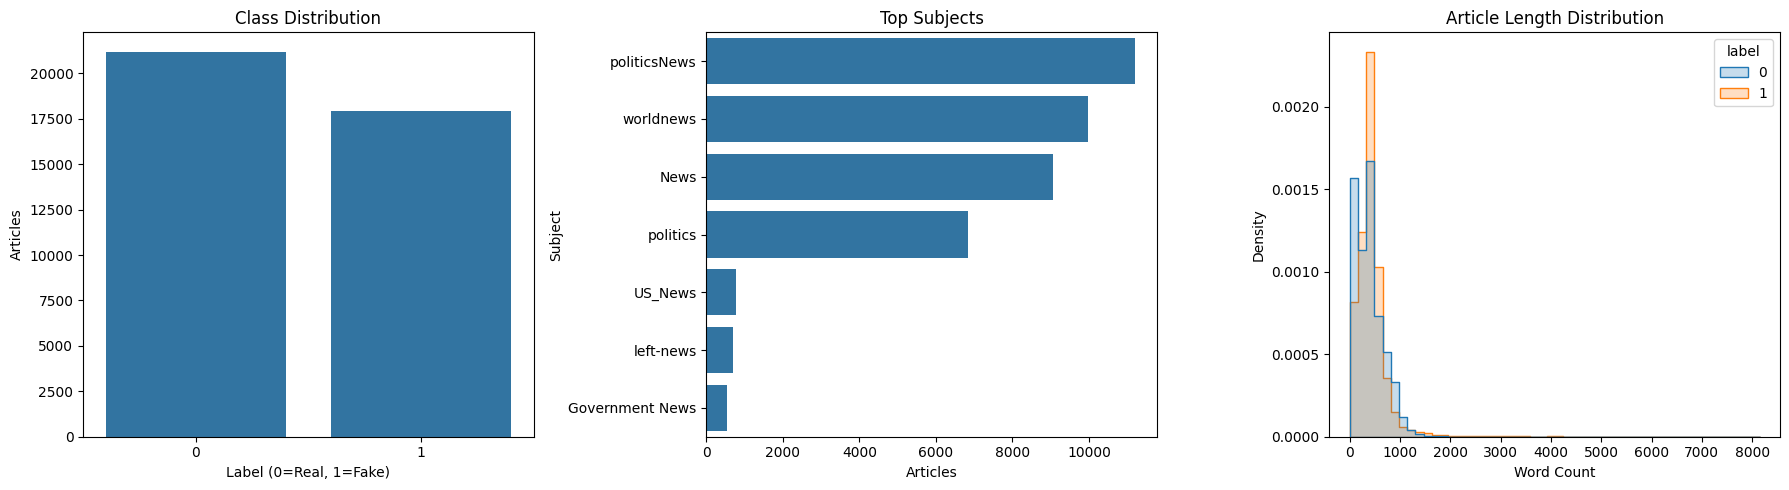


SUBJECT / LABEL RELATIONSHIP


label,0,1,Fake_Ratio
subject,,,
Government News,0.0,1.0,1.0
News,0.0,1.0,1.0
US_News,0.0,1.0,1.0
left-news,0.0,1.0,1.0
politics,0.0,1.0,1.0
politicsNews,1.0,0.0,0.0
worldnews,1.0,0.0,0.0



Methodological decision: `subject` is intentionally excluded from all predictive model features because it showed strong association with the target and may represent dataset/source leakage.


In [2]:
# ============================================================
# CELL 2 — LOAD + CLEAN + EDA
# ============================================================

from google.colab import files

print_section("UPLOAD DATASET")

uploaded = files.upload()

uploaded_files = list(uploaded.keys())

fake_file = next(
    (f for f in uploaded_files if f.lower() == "fake.csv"),
    None
)

true_file = next(
    (f for f in uploaded_files if f.lower() == "true.csv"),
    None
)

if fake_file is None or true_file is None:
    raise FileNotFoundError(
        "Please upload both Fake.csv and True.csv."
    )

fake_df = pd.read_csv(fake_file)
true_df = pd.read_csv(true_file)

fake_df["label"] = 1
true_df["label"] = 0

df = pd.concat(
    [fake_df, true_df],
    ignore_index=True
)

print(f"Raw Fake.csv: {len(fake_df):,}")
print(f"Raw True.csv: {len(true_df):,}")
print(f"Combined dataset: {len(df):,}")


# ------------------------------------------------------------
# Required columns
# ------------------------------------------------------------

required_columns = [
    "title",
    "text",
    "subject",
    "date",
    "label"
]

missing_columns = [
    c for c in required_columns
    if c not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )


# ------------------------------------------------------------
# Cleaning
# ------------------------------------------------------------

before = len(df)

df["title"] = df["title"].fillna("").map(clean_text)
df["text"] = df["text"].fillna("").map(clean_text)
df["subject"] = df["subject"].fillna("UNKNOWN").map(clean_text)
df["date"] = df["date"].fillna("").map(clean_text)

df = df[
    (df["title"].str.len() > 0) |
    (df["text"].str.len() > 0)
].copy()

df = df.drop_duplicates(
    subset=["title", "text"]
).reset_index(drop=True)

df["model_text"] = build_model_text(df)

df["text_only"] = df["text"]
df["title_only"] = df["title"]

df["date_parsed"] = pd.to_datetime(
    df["date"],
    errors="coerce",
    infer_datetime_format=True
)

df["text_length"] = df["model_text"].str.len()
df["word_count"] = df["model_text"].str.split().str.len()

after = len(df)

print(f"\nRows before cleaning: {before:,}")
print(f"Rows after cleaning:  {after:,}")
print(f"Removed rows:         {before - after:,}")


# ------------------------------------------------------------
# Dataset summary
# ------------------------------------------------------------

summary = pd.DataFrame({
    "Metric": [
        "Total articles",
        "Real articles",
        "Fake articles",
        "Real %",
        "Fake %",
        "Unique subjects",
        "Valid dates"
    ],
    "Value": [
        len(df),
        int((df["label"] == 0).sum()),
        int((df["label"] == 1).sum()),
        round((df["label"] == 0).mean() * 100, 2),
        round((df["label"] == 1).mean() * 100, 2),
        df["subject"].nunique(),
        df["date_parsed"].notna().sum()
    ]
})

display(summary)


# ------------------------------------------------------------
# EDA
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Class distribution
sns.countplot(
    data=df,
    x="label",
    ax=axes[0]
)
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("Label (0=Real, 1=Fake)")
axes[0].set_ylabel("Articles")

# Subject distribution
subject_counts = df["subject"].value_counts().head(15)

sns.barplot(
    x=subject_counts.values,
    y=subject_counts.index,
    ax=axes[1]
)
axes[1].set_title("Top Subjects")
axes[1].set_xlabel("Articles")
axes[1].set_ylabel("Subject")

# Text length
sns.histplot(
    data=df,
    x="word_count",
    hue="label",
    bins=50,
    element="step",
    stat="density",
    common_norm=False,
    ax=axes[2]
)
axes[2].set_title("Article Length Distribution")
axes[2].set_xlabel("Word Count")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Subject-label relationship
# ------------------------------------------------------------

subject_label = pd.crosstab(
    df["subject"],
    df["label"],
    normalize="index"
)

subject_label["Fake_Ratio"] = subject_label.get(1, 0)

print_section("SUBJECT / LABEL RELATIONSHIP")

display(
    subject_label
    .sort_values("Fake_Ratio", ascending=False)
    .head(15)
)

print(
    "\nMethodological decision: `subject` is intentionally excluded "
    "from all predictive model features because it showed strong "
    "association with the target and may represent dataset/source leakage."
)

In [3]:
# ============================================================
# CELL 3 — TRAIN / VALIDATION / TEST SPLIT
# ============================================================

print_section("DATA SPLITTING")

# Keep the original cleaned dataframe.
# subject remains available for analysis only.
# It will NEVER be passed to the predictive models.

train_df, temp_df = train_test_split(
    df,
    test_size=CONFIG["test_size"] + CONFIG["validation_size"],
    stratify=df["label"],
    random_state=SEED
)

relative_test_size = (
    CONFIG["test_size"] /
    (CONFIG["test_size"] + CONFIG["validation_size"])
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test_size,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train:      {len(train_df):,}")
print(f"Validation: {len(val_df):,}")
print(f"Test:       {len(test_df):,}")

print("\nClass distributions:")

split_summary = pd.DataFrame({
    "Train": train_df["label"].value_counts(normalize=True),
    "Validation": val_df["label"].value_counts(normalize=True),
    "Test": test_df["label"].value_counts(normalize=True)
}).sort_index()

display(split_summary)


# ------------------------------------------------------------
# Prepare text variants
# ------------------------------------------------------------

X_train = train_df["model_text"]
X_val = val_df["model_text"]
X_test = test_df["model_text"]

X_train_text = train_df["text_only"]
X_val_text = val_df["text_only"]
X_test_text = test_df["text_only"]

X_train_title = train_df["title_only"]
X_val_title = val_df["title_only"]
X_test_title = test_df["title_only"]

y_train = train_df["label"].values
y_val = val_df["label"].values
y_test = test_df["label"].values


# ------------------------------------------------------------
# TF-IDF
# ------------------------------------------------------------
# IMPORTANT:
# fit_transform ONLY on training data.
# Validation/test use transform only.

vectorizer = TfidfVectorizer(
    ngram_range=CONFIG["ngram_range"],
    max_features=CONFIG["max_features"],
    min_df=CONFIG["min_df"],
    max_df=CONFIG["max_df"],
    sublinear_tf=CONFIG["sublinear_tf"],
    strip_accents="unicode"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print("\nTF-IDF matrices:")
print("Train:", X_train_tfidf.shape)
print("Validation:", X_val_tfidf.shape)
print("Test:", X_test_tfidf.shape)

print(
    "\nLeakage control: TF-IDF vocabulary and statistics were "
    "learned from training data only."
)


DATA SPLITTING
Train:      27,370
Validation: 5,865
Test:       5,865

Class distributions:


,Train,Validation,Test
label,,,
0,0.542053,0.542029,0.542199
1,0.457947,0.457971,0.457801



TF-IDF matrices:
Train: (27370, 50000)
Validation: (5865, 50000)
Test: (5865, 50000)

Leakage control: TF-IDF vocabulary and statistics were learned from training data only.



CLASSICAL NLP MODEL BENCHMARK


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,
TF-IDF + Linear SVM,0.9964,0.9955,0.9966,0.9961,0.9998,0.9998
TF-IDF + Logistic Regression,0.9922,0.9948,0.9881,0.9914,0.9996,0.9996
TF-IDF + Naive Bayes,0.9616,0.9576,0.9587,0.9581,0.9928,0.9922



FINAL CLASSICAL BENCHMARK


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,
TF-IDF + Linear SVM,0.9964,0.9955,0.9966,0.9961,0.9998,0.9998
TF-IDF + Logistic Regression,0.9922,0.9948,0.9881,0.9914,0.9996,0.9996
TF-IDF Soft Voting Ensemble,0.9916,0.9929,0.9888,0.9909,0.9994,0.9993
TF-IDF + Naive Bayes,0.9616,0.9576,0.9587,0.9581,0.9928,0.9922


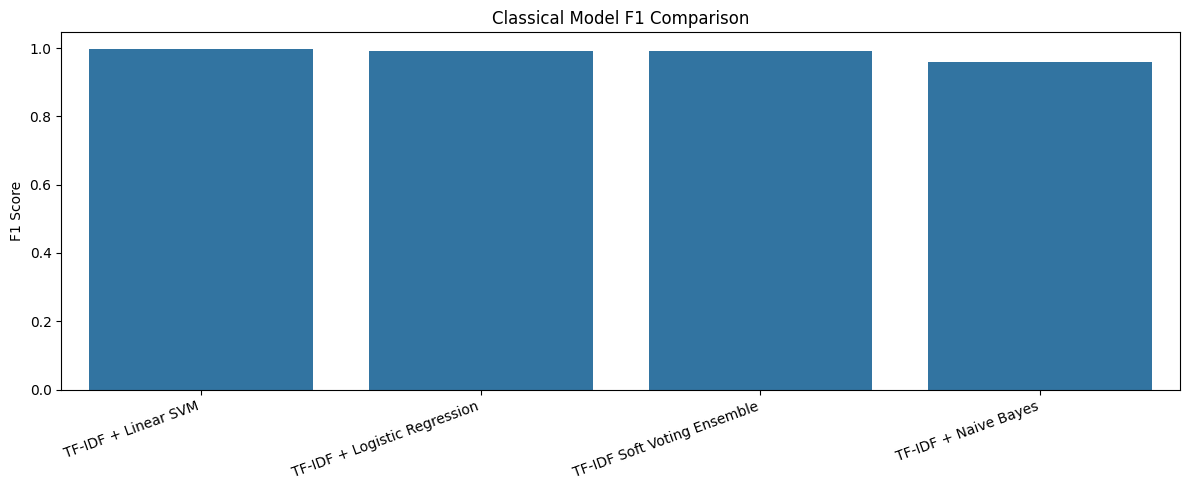

Best classical model: TF-IDF + Linear SVM


In [5]:
# ============================================================
# CELL 4 — CLASSICAL NLP BENCHMARK
# ============================================================

print_section("CLASSICAL NLP MODEL BENCHMARK")

models = {}

# ------------------------------------------------------------
# 1. Logistic Regression
# ------------------------------------------------------------

logistic_model = LogisticRegression(
    C=CONFIG["logistic_C"],
    max_iter=1000,
    class_weight=None,
    random_state=SEED
)

logistic_model.fit(
    X_train_tfidf,
    y_train
)

models["TF-IDF + Logistic Regression"] = logistic_model


# ------------------------------------------------------------
# 2. Calibrated Linear SVM
# ------------------------------------------------------------

svm_base = LinearSVC(
    C=1.0,
    random_state=SEED
)

svm_model = CalibratedClassifierCV(
    estimator=svm_base,
    cv=3,
    method="sigmoid"
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

models["TF-IDF + Linear SVM"] = svm_model


# ------------------------------------------------------------
# 3. Multinomial Naive Bayes
# ------------------------------------------------------------

nb_model = MultinomialNB(
    alpha=CONFIG["nb_alpha"]
)

nb_model.fit(
    X_train_tfidf,
    y_train
)

models["TF-IDF + Naive Bayes"] = nb_model


# ------------------------------------------------------------
# Evaluate
# ------------------------------------------------------------

classical_results = []
validation_probabilities = {}

for model_name, model in models.items():

    val_pred = model.predict(X_val_tfidf)

    if hasattr(model, "predict_proba"):
        val_prob = model.predict_proba(X_val_tfidf)[:, 1]
    else:
        val_prob = None

    validation_probabilities[model_name] = val_prob

    metrics = evaluate_predictions(
        y_val,
        val_pred,
        val_prob
    )

    metrics["Model"] = model_name
    classical_results.append(metrics)


classical_results_df = pd.DataFrame(
    classical_results
).set_index("Model").sort_values(
    "F1",
    ascending=False
)

display(
    classical_results_df.round(4)
)


# ------------------------------------------------------------
# Soft Voting Ensemble
# ------------------------------------------------------------

valid_probs = [
    validation_probabilities[name]
    for name in models
    if validation_probabilities[name] is not None
]

ensemble_val_prob = np.mean(
    np.vstack(valid_probs),
    axis=0
)

ensemble_val_pred = (
    ensemble_val_prob >= 0.50
).astype(int)

ensemble_metrics = evaluate_predictions(
    y_val,
    ensemble_val_pred,
    ensemble_val_prob
)

ensemble_metrics["Model"] = "TF-IDF Soft Voting Ensemble"

classical_results_df = pd.concat([
    classical_results_df,
    pd.DataFrame(
        [ensemble_metrics]
    ).set_index("Model")
])

classical_results_df = classical_results_df.sort_values(
    "F1",
    ascending=False
)

print_section("FINAL CLASSICAL BENCHMARK")

display(
    classical_results_df.round(4)
)


# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

plot_df = classical_results_df.reset_index()

plt.figure(figsize=(12, 5))

sns.barplot(
    data=plot_df,
    x="Model",
    y="F1"
)

plt.title("Classical Model F1 Comparison")
plt.xlabel("")
plt.ylabel("F1 Score")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Select best classical model
# ------------------------------------------------------------

best_classical_name = classical_results_df.index[0]

if best_classical_name == "TF-IDF Soft Voting Ensemble":
    best_classical_model = None
else:
    best_classical_model = models[best_classical_name]

print("Best classical model:", best_classical_name)

In [6]:
# ============================================================
# CELL 5 — DISTILBERT TRANSFORMER BASELINE
# ============================================================

print_section("DISTILBERT TRAINING")

# A lightweight subset can be used automatically on CPU
# to avoid making Colab unusable.
if DEVICE == "cuda":
    transformer_train_df = train_df.copy()
    transformer_val_df = val_df.copy()
else:
    MAX_CPU_TRAIN = min(12_000, len(train_df))
    MAX_CPU_VAL = min(3_000, len(val_df))

    transformer_train_df = (
        train_df
        .groupby("label", group_keys=False)
        .apply(
            lambda x: x.sample(
                n=min(
                    len(x),
                    MAX_CPU_TRAIN // 2
                ),
                random_state=SEED
            )
        )
        .reset_index(drop=True)
    )

    transformer_val_df = (
        val_df
        .groupby("label", group_keys=False)
        .apply(
            lambda x: x.sample(
                n=min(
                    len(x),
                    MAX_CPU_VAL // 2
                ),
                random_state=SEED
            )
        )
        .reset_index(drop=True)
    )

print(f"Transformer train size: {len(transformer_train_df):,}")
print(f"Transformer validation size: {len(transformer_val_df):,}")


# ------------------------------------------------------------
# Tokenizer
# ------------------------------------------------------------

tokenizer = AutoTokenizer.from_pretrained(
    CONFIG["transformer_name"]
)


class NewsDataset(torch.utils.data.Dataset):

    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length
        )

        encoding["labels"] = self.labels[idx]

        return {
            key: torch.tensor(value)
            for key, value in encoding.items()
        }


transformer_train_dataset = NewsDataset(
    transformer_train_df["model_text"],
    transformer_train_df["label"],
    tokenizer,
    CONFIG["max_length"]
)

transformer_val_dataset = NewsDataset(
    transformer_val_df["model_text"],
    transformer_val_df["label"],
    tokenizer,
    CONFIG["max_length"]
)


# ------------------------------------------------------------
# Model
# ------------------------------------------------------------

transformer_model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["transformer_name"],
    num_labels=2
)


def compute_transformer_metrics(eval_pred):

    logits, labels = eval_pred

    probabilities = torch.softmax(
        torch.tensor(logits),
        dim=1
    ).numpy()[:, 1]

    predictions = (
        probabilities >= 0.50
    ).astype(int)

    return evaluate_predictions(
        labels,
        predictions,
        probabilities
    )


training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR / "distilbert"),
    num_train_epochs=CONFIG["transformer_epochs"],
    per_device_train_batch_size=CONFIG["transformer_batch_size"],
    per_device_eval_batch_size=CONFIG["transformer_batch_size"],
    learning_rate=5e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="no",
    logging_strategy="steps",
    logging_steps=100,
    report_to="none",
    seed=SEED,
    fp16=torch.cuda.is_available()
)

trainer = Trainer(
    model=transformer_model,
    args=training_args,
    train_dataset=transformer_train_dataset,
    eval_dataset=transformer_val_dataset,
    compute_metrics=compute_transformer_metrics
)

trainer.train()

transformer_eval = trainer.evaluate()

transformer_metrics = pd.DataFrame([{
    "Model": "DistilBERT",
    "Accuracy": transformer_eval.get("eval_Accuracy", np.nan),
    "Precision": transformer_eval.get("eval_Precision", np.nan),
    "Recall": transformer_eval.get("eval_Recall", np.nan),
    "F1": transformer_eval.get("eval_F1", np.nan),
    "ROC-AUC": transformer_eval.get("eval_ROC-AUC", np.nan),
    "PR-AUC": transformer_eval.get("eval_PR-AUC", np.nan)
}]).set_index("Model")

print_section("TRANSFORMER RESULTS")

display(transformer_metrics.round(4))

print(
    "\nNote: On CPU, a balanced subset is automatically used "
    "to keep runtime practical. GPU runs use the full cleaned split."
)


DISTILBERT TRAINING
Transformer train size: 27,370
Transformer validation size: 5,865


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc-auc,Pr-auc
1,0.008883,0.005390,0.999147,0.998142,1.000000,0.999070,0.999989,0.999987
2,0.006526,0.002343,0.999659,0.999256,1.000000,0.999628,1.000000,1.000000


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Roc-auc,Pr-auc
0.006526,0.002343,2,0.999659,0.999256,1.000000,0.999628,1.000000,1.000000



TRANSFORMER RESULTS


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,
DistilBERT,0.9997,0.9993,1.0,0.9996,1.0,1.0



Note: On CPU, a balanced subset is automatically used to keep runtime practical. GPU runs use the full cleaned split.


In [7]:
# ============================================================
# CELL 6 — LEAKAGE / ARTIFACT ANALYSIS
# ============================================================

print_section("LEAKAGE / ARTIFACT ANALYSIS")


def run_logistic_experiment(
    train_text,
    val_text,
    train_labels,
    val_labels,
    name
):
    """
    Independent experiment.
    Vectorizer is fitted ONLY on experiment training data.
    """

    vec = TfidfVectorizer(
        ngram_range=CONFIG["ngram_range"],
        max_features=CONFIG["max_features"],
        min_df=CONFIG["min_df"],
        max_df=CONFIG["max_df"],
        sublinear_tf=True,
        strip_accents="unicode"
    )

    Xtr = vec.fit_transform(train_text)
    Xv = vec.transform(val_text)

    model = LogisticRegression(
        C=CONFIG["logistic_C"],
        max_iter=1000,
        random_state=SEED
    )

    model.fit(Xtr, train_labels)

    prob = model.predict_proba(Xv)[:, 1]
    pred = (prob >= 0.50).astype(int)

    metrics = evaluate_predictions(
        val_labels,
        pred,
        prob
    )

    metrics["Experiment"] = name

    return metrics


# ------------------------------------------------------------
# A. Title + Text
# ------------------------------------------------------------

exp_full = run_logistic_experiment(
    train_df["model_text"],
    val_df["model_text"],
    y_train,
    y_val,
    "Title + Text"
)


# ------------------------------------------------------------
# B. Text only
# ------------------------------------------------------------

exp_text = run_logistic_experiment(
    train_df["text_only"],
    val_df["text_only"],
    y_train,
    y_val,
    "Text Only"
)


# ------------------------------------------------------------
# C. Title only
# ------------------------------------------------------------

exp_title = run_logistic_experiment(
    train_df["title_only"],
    val_df["title_only"],
    y_train,
    y_val,
    "Title Only"
)


# ------------------------------------------------------------
# D. Artifact-cleaned Title + Text
# ------------------------------------------------------------

train_artifact = train_df["model_text"].map(
    artifact_clean_text
)

val_artifact = val_df["model_text"].map(
    artifact_clean_text
)

exp_artifact = run_logistic_experiment(
    train_artifact,
    val_artifact,
    y_train,
    y_val,
    "Artifact-Reduced Title + Text"
)


artifact_results = pd.DataFrame([
    exp_full,
    exp_text,
    exp_title,
    exp_artifact
]).set_index("Experiment")

print_section("CONTROLLED ARTIFACT EXPERIMENTS")

display(
    artifact_results.round(4)
)


# ------------------------------------------------------------
# Artifact frequency analysis
# ------------------------------------------------------------

artifact_patterns = [
    "Reuters",
    "Washington Reuters",
    "via",
    "read more",
    "featured image",
    "image",
    "source",
    "publisher"
]

artifact_frequency = []

combined_text_lower = df["model_text"].str.lower()

for pattern in artifact_patterns:

    mask = combined_text_lower.str.contains(
        re.escape(pattern.lower()),
        regex=True,
        na=False
    )

    artifact_frequency.append({
        "Artifact": pattern,
        "Articles containing artifact": int(mask.sum()),
        "Percentage": round(mask.mean() * 100, 3),
        "Fake rate among matches": round(
            df.loc[mask, "label"].mean() * 100,
            3
        ) if mask.sum() else np.nan
    })

artifact_frequency_df = pd.DataFrame(
    artifact_frequency
)

print_section("ARTIFACT FREQUENCY")

display(artifact_frequency_df)


# ------------------------------------------------------------
# Automatic interpretation
# ------------------------------------------------------------

full_f1 = exp_full["F1"]
text_f1 = exp_text["F1"]
title_f1 = exp_title["F1"]
artifact_f1 = exp_artifact["F1"]

print_section("AUTOMATIC INTERPRETATION")

print(
    f"Title + Text F1: {full_f1:.4f}"
)
print(
    f"Text-only F1: {text_f1:.4f}"
)
print(
    f"Title-only F1: {title_f1:.4f}"
)
print(
    f"Artifact-reduced F1: {artifact_f1:.4f}"
)

if full_f1 - text_f1 > 0.02:
    print(
        "\nFinding: title information materially contributes to performance."
    )

if title_f1 > 0.80:
    print(
        "Finding: title-only performance is unusually strong; "
        "this suggests headline/style shortcuts may exist."
    )

if full_f1 - artifact_f1 > 0.02:
    print(
        "Finding: removing common source/style artifacts causes "
        "a material performance drop, indicating possible artifact leakage."
    )
else:
    print(
        "Finding: removing the tested artifacts does not materially "
        "change performance."
    )

print(
    "\nInterpretation rule: high performance is treated as learned "
    "dataset-specific classification behavior, not evidence that the "
    "system fact-checks the underlying claims."
)


LEAKAGE / ARTIFACT ANALYSIS

CONTROLLED ARTIFACT EXPERIMENTS


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Experiment,,,,,,
Title + Text,0.9922,0.9948,0.9881,0.9914,0.9996,0.9996
Text Only,0.9911,0.9940,0.9866,0.9903,0.9996,0.9995
Title Only,0.9535,0.9586,0.9389,0.9487,0.9908,0.9873
Artifact-Reduced Title + Text,0.9876,0.9914,0.9814,0.9863,0.9992,0.9991



ARTIFACT FREQUENCY


,Artifact,Articles containing artifact,Percentage,Fake rate among matches
0,Reuters,21377,54.673,1.029
1,Washington Reuters,0,0.000,NaN
2,via,10972,28.061,89.929
3,read more,1723,4.407,99.478
4,featured image,8160,20.870,100.000
5,image,9812,25.095,94.782
6,source,5112,13.074,39.613
7,publisher,123,0.315,52.033



AUTOMATIC INTERPRETATION
Title + Text F1: 0.9914
Text-only F1: 0.9903
Title-only F1: 0.9487
Artifact-reduced F1: 0.9863
Finding: title-only performance is unusually strong; this suggests headline/style shortcuts may exist.
Finding: removing the tested artifacts does not materially change performance.

Interpretation rule: high performance is treated as learned dataset-specific classification behavior, not evidence that the system fact-checks the underlying claims.



THRESHOLD OPTIMIZATION
Optimal validation threshold: 0.36


,threshold,precision,recall,f1
11,0.41,0.9952,0.9974,0.9963
10,0.40,0.9952,0.9974,0.9963
9,0.39,0.9952,0.9974,0.9963
8,0.38,0.9952,0.9974,0.9963
7,0.37,0.9952,0.9974,0.9963
6,0.36,0.9952,0.9974,0.9963
16,0.46,0.9955,0.9970,0.9963
18,0.48,0.9955,0.9970,0.9963
17,0.47,0.9955,0.9970,0.9963
12,0.42,0.9952,0.9970,0.9961


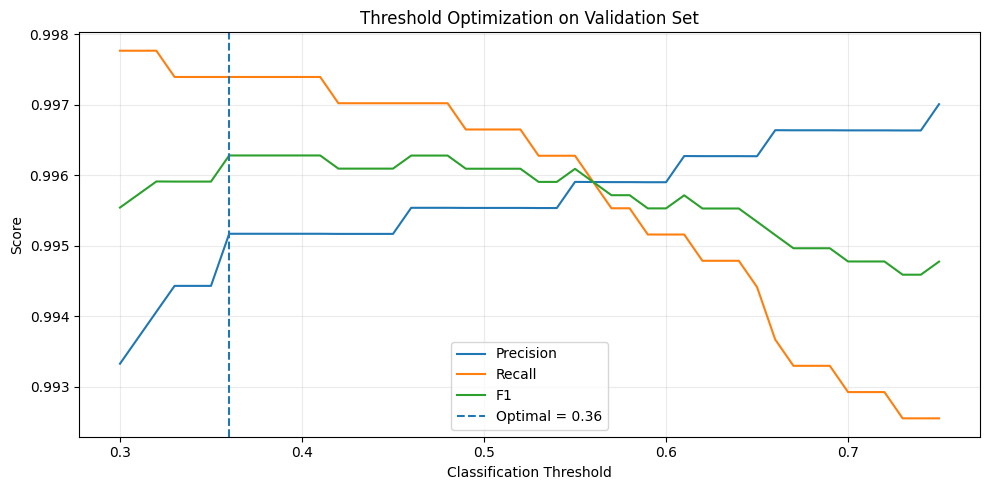


FINAL TEST PERFORMANCE


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,
TF-IDF + Linear SVM,0.9951,0.994,0.9952,0.9946,0.9997,0.9997



CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Real News     0.9959    0.9950    0.9954      3180
   Fake News     0.9940    0.9952    0.9946      2685

    accuracy                         0.9951      5865
   macro avg     0.9950    0.9951    0.9950      5865
weighted avg     0.9951    0.9951    0.9951      5865



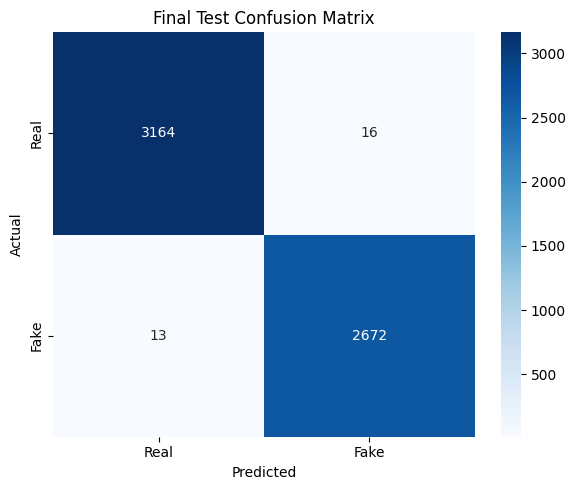

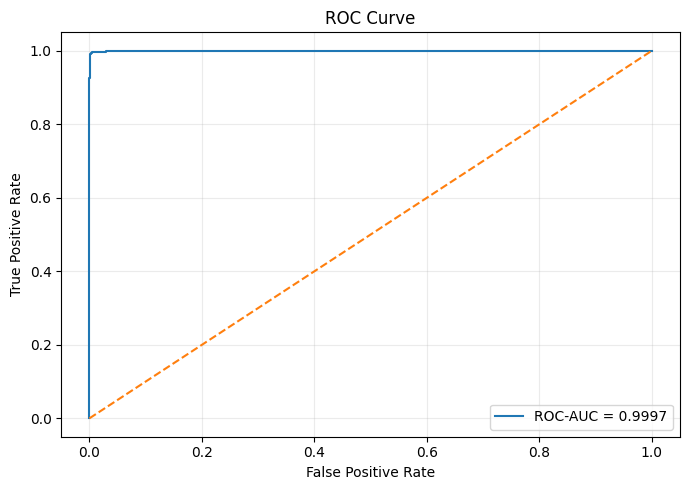

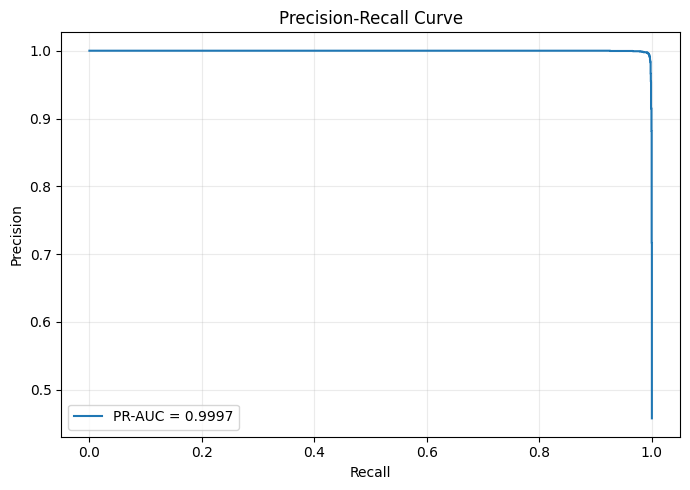


Important: feature importance represents model associations with dataset labels. It is NOT evidence that a word or phrase proves a news article is factually false or true.


In [8]:
# ============================================================
# CELL 7 — THRESHOLD OPTIMIZATION + FINAL TEST + EXPLAINABILITY
# ============================================================

print_section("THRESHOLD OPTIMIZATION")


# ------------------------------------------------------------
# Get best classical validation probabilities
# ------------------------------------------------------------

if best_classical_name == "TF-IDF Soft Voting Ensemble":

    best_val_prob = ensemble_val_prob

else:

    best_val_prob = validation_probabilities[
        best_classical_name
    ]


threshold_results, optimal_threshold = threshold_search(
    y_val,
    best_val_prob,
    CONFIG["threshold_grid"]
)

print(
    f"Optimal validation threshold: {optimal_threshold:.2f}"
)

display(
    threshold_results.sort_values(
        "f1",
        ascending=False
    ).head(10).round(4)
)


# ------------------------------------------------------------
# Threshold plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    label="Precision"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    label="Recall"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["f1"],
    label="F1"
)

plt.axvline(
    optimal_threshold,
    linestyle="--",
    label=f"Optimal = {optimal_threshold:.2f}"
)

plt.title("Threshold Optimization on Validation Set")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Final Test Probabilities
# ------------------------------------------------------------

if best_classical_name == "TF-IDF Soft Voting Ensemble":

    test_probabilities = np.mean(
        np.vstack([
            model.predict_proba(X_test_tfidf)[:, 1]
            for model in models.values()
        ]),
        axis=0
    )

else:

    best_model = models[best_classical_name]

    test_probabilities = (
        best_model
        .predict_proba(X_test_tfidf)[:, 1]
    )


test_predictions = (
    test_probabilities >= optimal_threshold
).astype(int)


final_metrics = evaluate_predictions(
    y_test,
    test_predictions,
    test_probabilities
)

final_results = pd.DataFrame([
    {
        "Model": best_classical_name,
        **final_metrics
    }
]).set_index("Model")

print_section("FINAL TEST PERFORMANCE")

display(
    final_results.round(4)
)


# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

print_section("CLASSIFICATION REPORT")

print(
    classification_report(
        y_test,
        test_predictions,
        target_names=["Real News", "Fake News"],
        digits=4
    )
)


# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    test_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real", "Fake"],
    yticklabels=["Real", "Fake"]
)

plt.title("Final Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# ROC Curve
# ------------------------------------------------------------

fpr, tpr, _ = roc_curve(
    y_test,
    test_probabilities
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {final_metrics['ROC-AUC']:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Precision-Recall Curve
# ------------------------------------------------------------

precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    test_probabilities
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"PR-AUC = {final_metrics['PR-AUC']:.4f}"
)

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Explainability — TF-IDF linear model
# ------------------------------------------------------------

if best_classical_name != "TF-IDF Soft Voting Ensemble":

    classifier = best_classical_model

    if hasattr(classifier, "coef_"):

        feature_names = np.array(
            vectorizer.get_feature_names_out()
        )

        coefficients = classifier.coef_[0]

        fake_idx = np.argsort(coefficients)[-25:][::-1]
        real_idx = np.argsort(coefficients)[:25]

        fake_features = pd.DataFrame({
            "Feature": feature_names[fake_idx],
            "Coefficient": coefficients[fake_idx]
        })

        real_features = pd.DataFrame({
            "Feature": feature_names[real_idx],
            "Coefficient": coefficients[real_idx]
        })

        print_section("TOP FEATURES ASSOCIATED WITH FAKE NEWS")

        display(fake_features)

        print_section("TOP FEATURES ASSOCIATED WITH REAL NEWS")

        display(real_features)

else:
    print(
        "The ensemble does not expose a single coefficient vector. "
        "Explainability is therefore shown using the individual "
        "Logistic Regression model."
    )

    coefficients = logistic_model.coef_[0]

    feature_names = np.array(
        vectorizer.get_feature_names_out()
    )

    fake_idx = np.argsort(coefficients)[-25:][::-1]
    real_idx = np.argsort(coefficients)[:25]

    display(pd.DataFrame({
        "Feature": feature_names[fake_idx],
        "Coefficient": coefficients[fake_idx]
    }))

    display(pd.DataFrame({
        "Feature": feature_names[real_idx],
        "Coefficient": coefficients[real_idx]
    }))

print(
    "\nImportant: feature importance represents model associations "
    "with dataset labels. It is NOT evidence that a word or phrase "
    "proves a news article is factually false or true."
)


DETAILED ERROR ANALYSIS

HIGHEST-CONFIDENCE FALSE POSITIVES


,title,label,prediction,confidence,subject
1076,A Picture and its Story: Reaching out to rescu...,0,1,0.994419,worldnews
2702,GENERATION GAP: China's one-child generation g...,0,1,0.970333,worldnews
4854,Highlights of Reuters interview with Trump,0,1,0.934640,politicsNews
3076,"The Big Squeeze: This election year, it’s all ...",0,1,0.908212,politicsNews
1983,"ASPIRATIONS: Young Chinese seize the day, seiz...",0,1,0.859211,worldnews
3659,Obama says more must be done to address U.S. p...,0,1,0.835599,politicsNews
4573,Trump firing of FBI Director Comey evokes crit...,0,1,0.710522,politicsNews
2833,INSTANT VIEW: Reactions to grand jury subpoena...,0,1,0.709157,politicsNews
5644,Hillary Clinton spars with comedian on parody ...,0,1,0.676665,politicsNews
4080,Highlights of Reuters interview with Trump,0,1,0.669983,politicsNews



HIGHEST-CONFIDENCE FALSE NEGATIVES


,title,label,prediction,confidence,subject
4909,IS OBAMA’S RADICAL AGENDA Responsible For Stat...,1,0,0.999661,politics
329,"POPE MEETS WITH ANGRY, JEWISH, PR0 LATE-TERM A...",1,0,0.996093,politics
998,BREAKING: RUSSIA SMELLS OBAMA’S FOREIGN POLICY...,1,0,0.992896,politics
5025,WOW! THE WASHINGTON POST Publishes #RealNews S...,1,0,0.992729,politics
2105,AS TRUMP’S POPULARITY SOARS ABROAD…Village In ...,1,0,0.978420,politics
956,NOT KIDDING: PA College Cancels Play After Aut...,1,0,0.964792,left-news
3325,FOLLOW THE MONEY: MEXICAN GIVEAWAY OF MILLIONS...,1,0,0.904852,Government News
3507,EU LEADERS PLEDGE EXTRA €1 Billion In Aid To R...,1,0,0.894658,Government News
2725,BRILLIANT! President Trump Offers Congress Har...,1,0,0.872796,politics
4918,BREAKING: Trump Reportedly Considering Ted Cru...,1,0,0.792155,politics



LOWEST-CONFIDENCE PREDICTIONS


,title,label,prediction,confidence,error_type
1490,SENATE PASSES USA FREEDOM ACT,1,1,0.511462,Correct
5108,INTERNET: Living with the Great Firewall of China,0,1,0.527436,False Positive
1937,OOPS! UKRAINE Caught Colluding With Democrats ...,1,1,0.528259,Correct
1525,Factbox: Trump plan to dismantle 'Dreamer' pro...,0,1,0.532441,False Positive
5326,Colorado judge rejects request to extend votin...,0,1,0.555564,False Positive
2001,Suppressing free press is 'how dictators get s...,0,1,0.561385,False Positive
3323,LIVE FEED: HEARING FOR SENATOR SESSIONS To Inc...,1,1,0.587863,Correct
453,Guantanamo shrinking but Obama goal of closing...,0,1,0.590357,False Positive
2770,Saudi Prince Arrested In LA For Sexual Assault...,1,1,0.606211,Correct
1595,IS TRUMP DITCHING Obama’s “Bad Deal” to Bring ...,1,1,0.606933,Correct


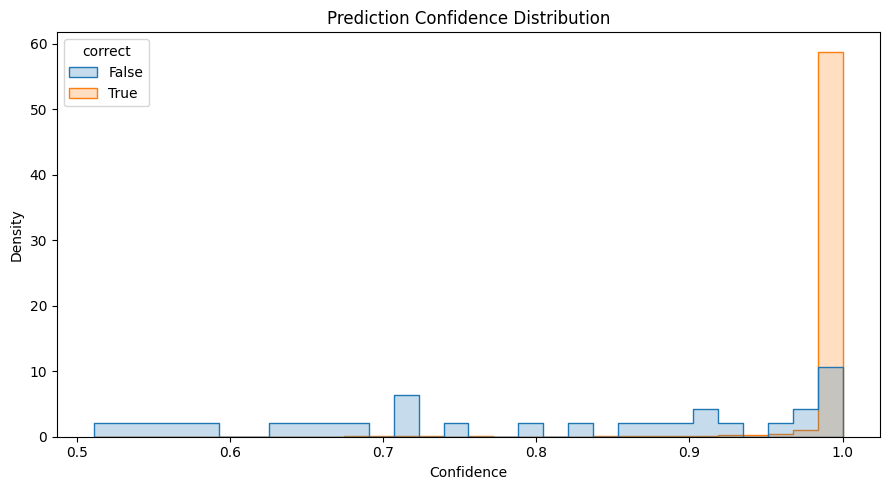


SUBJECT-LEVEL ERROR DISTRIBUTION


,Articles,Real,Fake,F1,False_Positives,False_Negatives,FP_Rate,FN_Rate,Error_Rate
subject,,,,,,,,,
Government News,93.0,0.0,93.0,0.9891,0.0,2.0,NaN,0.0215,0.0215
left-news,95.0,0.0,95.0,0.9947,0.0,1.0,NaN,0.0105,0.0105
politics,1074.0,0.0,1074.0,0.9953,0.0,10.0,NaN,0.0093,0.0093
politicsNews,1670.0,1670.0,0.0,0.0000,12.0,0.0,0.0072,NaN,0.0072
worldnews,1510.0,1510.0,0.0,0.0000,4.0,0.0,0.0026,NaN,0.0026
US_News,103.0,0.0,103.0,1.0000,0.0,0.0,NaN,0.0000,0.0000
News,1320.0,0.0,1320.0,1.0000,0.0,0.0,NaN,0.0000,0.0000



AUTOMATIC ERROR INTERPRETATION
Highest-error subjects: ['Government News', 'left-news', 'politics', 'politicsNews', 'worldnews']
Overall test error rate: 0.0049
False positives: 16
False negatives: 13

Interpretation: subject-level variation is treated as an important diagnostic signal because subject was excluded from model features but may still reveal dataset construction or distribution differences.


In [9]:
# ============================================================
# CELL 8 — ERROR ANALYSIS
# ============================================================

print_section("DETAILED ERROR ANALYSIS")

error_df = test_df[
    ["title", "text", "subject", "label"]
].copy()

error_df["probability_fake"] = test_probabilities
error_df["prediction"] = test_predictions
error_df["confidence"] = np.where(
    test_probabilities >= 0.5,
    test_probabilities,
    1 - test_probabilities
)

error_df["correct"] = (
    error_df["label"] ==
    error_df["prediction"]
)

error_df["error_type"] = np.select(
    [
        (error_df["label"] == 0) &
        (error_df["prediction"] == 1),

        (error_df["label"] == 1) &
        (error_df["prediction"] == 0)
    ],
    [
        "False Positive",
        "False Negative"
    ],
    default="Correct"
)


# ------------------------------------------------------------
# False Positives
# ------------------------------------------------------------

fp_df = (
    error_df[
        error_df["error_type"] == "False Positive"
    ]
    .sort_values("confidence", ascending=False)
    .head(15)
)

print_section("HIGHEST-CONFIDENCE FALSE POSITIVES")

display(
    fp_df[
        [
            "title",
            "label",
            "prediction",
            "confidence",
            "subject"
        ]
    ]
)


# ------------------------------------------------------------
# False Negatives
# ------------------------------------------------------------

fn_df = (
    error_df[
        error_df["error_type"] == "False Negative"
    ]
    .sort_values("confidence", ascending=False)
    .head(15)
)

print_section("HIGHEST-CONFIDENCE FALSE NEGATIVES")

display(
    fn_df[
        [
            "title",
            "label",
            "prediction",
            "confidence",
            "subject"
        ]
    ]
)


# ------------------------------------------------------------
# Lowest confidence
# ------------------------------------------------------------

uncertain_df = (
    error_df
    .sort_values("confidence", ascending=True)
    .head(15)
)

print_section("LOWEST-CONFIDENCE PREDICTIONS")

display(
    uncertain_df[
        [
            "title",
            "label",
            "prediction",
            "confidence",
            "error_type"
        ]
    ]
)


# ------------------------------------------------------------
# Confidence distribution
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

sns.histplot(
    data=error_df,
    x="confidence",
    hue="correct",
    bins=30,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Density")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Subject-level error analysis
# ------------------------------------------------------------

def subject_error_metrics(group):

    y_true_subject = group["label"]
    y_pred_subject = group["prediction"]

    fp = (
        (y_true_subject == 0) &
        (y_pred_subject == 1)
    ).sum()

    fn = (
        (y_true_subject == 1) &
        (y_pred_subject == 0)
    ).sum()

    negatives = (y_true_subject == 0).sum()
    positives = (y_true_subject == 1).sum()

    return pd.Series({
        "Articles": len(group),
        "Real": negatives,
        "Fake": positives,
        "F1": f1_score(
            y_true_subject,
            y_pred_subject,
            zero_division=0
        ),
        "False_Positives": fp,
        "False_Negatives": fn,
        "FP_Rate": fp / negatives if negatives else np.nan,
        "FN_Rate": fn / positives if positives else np.nan,
        "Error_Rate": (
            (y_true_subject != y_pred_subject).mean()
        )
    })


subject_error_results = (
    error_df
    .groupby("subject")
    .apply(subject_error_metrics)
    .sort_values("Error_Rate", ascending=False)
)

print_section("SUBJECT-LEVEL ERROR DISTRIBUTION")

display(
    subject_error_results
    .head(25)
    .round(4)
)


# ------------------------------------------------------------
# Automatic error interpretation
# ------------------------------------------------------------

major_subjects = (
    subject_error_results
    .head(5)
    .index
    .tolist()
)

print_section("AUTOMATIC ERROR INTERPRETATION")

print(
    f"Highest-error subjects: {major_subjects}"
)

print(
    f"Overall test error rate: "
    f"{(error_df['correct'] == False).mean():.4f}"
)

print(
    f"False positives: "
    f"{(error_df['error_type'] == 'False Positive').sum():,}"
)

print(
    f"False negatives: "
    f"{(error_df['error_type'] == 'False Negative').sum():,}"
)

print(
    "\nInterpretation: subject-level variation is treated as an "
    "important diagnostic signal because subject was excluded from "
    "model features but may still reveal dataset construction "
    "or distribution differences."
)


TRUE TEMPORAL EVALUATION
Temporal cutoff: 2017-10-25 00:00:00
Temporal training samples: 25,519
Temporal test samples:     6,296
Training date range: 2015-05-01 00:00:00 → 2017-10-25 00:00:00
Test date range: 2017-10-26 00:00:00 → 2017-12-31 00:00:00

RANDOM VS TEMPORAL PERFORMANCE


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Evaluation,,,,,,
Random Test Split,0.9951,0.9940,0.9952,0.9946,0.9997,0.9997
True Temporal Test,0.9990,0.9785,0.9956,0.9870,0.9999,0.9986


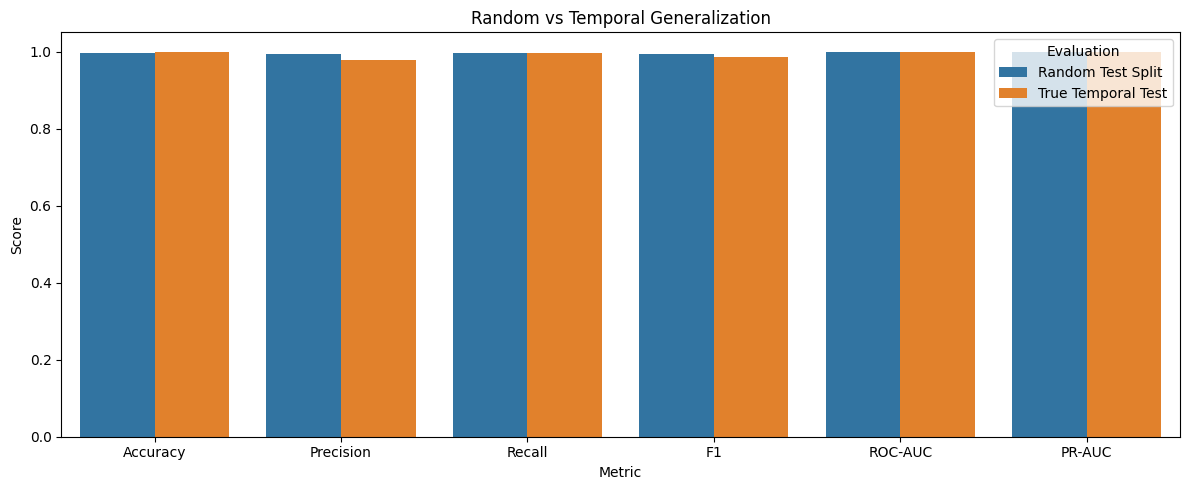


TEMPORAL ROBUSTNESS INTERPRETATION
F1 change:      +0.0076
ROC-AUC change: -0.0003

Finding: temporal degradation is relatively small. The learned patterns appear comparatively stable over time.


In [10]:
# ============================================================
# CELL 9 — TRUE OUT-OF-TIME TEMPORAL EVALUATION
# ============================================================

print_section("TRUE TEMPORAL EVALUATION")

temporal_df = df[
    df["date_parsed"].notna()
].copy()

temporal_df = temporal_df.sort_values(
    "date_parsed"
).reset_index(drop=True)

if len(temporal_df) < 1000:
    raise ValueError(
        "Not enough valid dates for a meaningful temporal evaluation."
    )


# ------------------------------------------------------------
# 80% historical training / 20% future test
# ------------------------------------------------------------

temporal_cutoff = temporal_df["date_parsed"].quantile(0.80)

temporal_train = temporal_df[
    temporal_df["date_parsed"] <= temporal_cutoff
].copy()

temporal_test = temporal_df[
    temporal_df["date_parsed"] > temporal_cutoff
].copy()

print("Temporal cutoff:", temporal_cutoff)

print(
    f"Temporal training samples: {len(temporal_train):,}"
)

print(
    f"Temporal test samples:     {len(temporal_test):,}"
)

print(
    f"Training date range: "
    f"{temporal_train['date_parsed'].min()} "
    f"→ "
    f"{temporal_train['date_parsed'].max()}"
)

print(
    f"Test date range: "
    f"{temporal_test['date_parsed'].min()} "
    f"→ "
    f"{temporal_test['date_parsed'].max()}"
)


# ------------------------------------------------------------
# Train fresh TF-IDF + Logistic Regression
# ------------------------------------------------------------

temporal_vectorizer = TfidfVectorizer(
    ngram_range=CONFIG["ngram_range"],
    max_features=CONFIG["max_features"],
    min_df=CONFIG["min_df"],
    max_df=CONFIG["max_df"],
    sublinear_tf=True,
    strip_accents="unicode"
)

X_temporal_train = temporal_vectorizer.fit_transform(
    temporal_train["model_text"]
)

X_temporal_test = temporal_vectorizer.transform(
    temporal_test["model_text"]
)

y_temporal_train = temporal_train["label"].values
y_temporal_test = temporal_test["label"].values

temporal_model = LogisticRegression(
    C=CONFIG["logistic_C"],
    max_iter=1000,
    random_state=SEED
)

temporal_model.fit(
    X_temporal_train,
    y_temporal_train
)

temporal_prob = (
    temporal_model
    .predict_proba(X_temporal_test)[:, 1]
)

temporal_pred = (
    temporal_prob >= 0.50
).astype(int)

temporal_metrics = evaluate_predictions(
    y_temporal_test,
    temporal_pred,
    temporal_prob
)


# ------------------------------------------------------------
# Compare random vs temporal
# ------------------------------------------------------------

random_metrics = final_metrics.copy()

comparison = pd.DataFrame([
    {
        "Evaluation": "Random Test Split",
        **random_metrics
    },
    {
        "Evaluation": "True Temporal Test",
        **temporal_metrics
    }
]).set_index("Evaluation")

print_section("RANDOM VS TEMPORAL PERFORMANCE")

display(
    comparison.round(4)
)


# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC"
]

plot_data = comparison[metrics_to_plot].reset_index()

plot_long = plot_data.melt(
    id_vars="Evaluation",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=plot_long,
    x="Metric",
    y="Score",
    hue="Evaluation"
)

plt.ylim(0, 1.05)
plt.title("Random vs Temporal Generalization")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Automatic temporal interpretation
# ------------------------------------------------------------

f1_drop = (
    random_metrics["F1"] -
    temporal_metrics["F1"]
)

auc_drop = (
    random_metrics["ROC-AUC"] -
    temporal_metrics["ROC-AUC"]
)

print_section("TEMPORAL ROBUSTNESS INTERPRETATION")

print(f"F1 change:      {f1_drop:+.4f}")
print(f"ROC-AUC change: {auc_drop:+.4f}")

if f1_drop > 0.05:
    print(
        "\nFinding: performance drops materially on future data. "
        "This indicates temporal distribution shift and/or "
        "dataset-specific shortcuts."
    )
elif f1_drop > 0.02:
    print(
        "\nFinding: there is a moderate temporal performance drop. "
        "The model generalizes reasonably but is affected by time."
    )
else:
    print(
        "\nFinding: temporal degradation is relatively small. "
        "The learned patterns appear comparatively stable over time."
    )

In [11]:
# ============================================================
# CELL 10 — PRODUCTION + SERIALIZATION + FINAL REPORT
# ============================================================

print_section("PRODUCTION PACKAGE")


# ------------------------------------------------------------
# Production inference model
# ------------------------------------------------------------
# For production simplicity, use the best SINGLE classical model.
# If ensemble wins, Logistic Regression becomes the serialized
# production baseline because it provides stable probabilities
# and interpretable coefficients.

if best_classical_name == "TF-IDF Soft Voting Ensemble":
    production_model = logistic_model
    production_model_name = "TF-IDF + Logistic Regression"
else:
    production_model = best_classical_model
    production_model_name = best_classical_name


# ------------------------------------------------------------
# Production inference
# ------------------------------------------------------------

def predict_misinformation(text):
    """
    Production inference function.

    Returns:
        prediction
        probability_fake
        confidence
        threshold
    """

    if not isinstance(text, str) or not text.strip():
        raise ValueError(
            "Input text must be a non-empty string."
        )

    cleaned = clean_text(text)

    vectorized = vectorizer.transform(
        [cleaned]
    )

    probability_fake = float(
        production_model
        .predict_proba(vectorized)[0, 1]
    )

    prediction = int(
        probability_fake >= optimal_threshold
    )

    confidence = float(
        probability_fake
        if prediction == 1
        else 1 - probability_fake
    )

    return {
        "prediction": prediction,
        "probability_fake": round(
            probability_fake,
            6
        ),
        "confidence": round(
            confidence,
            6
        ),
        "threshold": round(
            optimal_threshold,
            6
        )
    }


# ------------------------------------------------------------
# Example inference
# ------------------------------------------------------------

example_text = (
    "The government announced a new policy after a meeting "
    "with senior officials."
)

print("Example prediction:")
print(
    json.dumps(
        predict_misinformation(example_text),
        indent=4
    )
)


# ------------------------------------------------------------
# Save model package
# ------------------------------------------------------------

model_package = {
    "model": production_model,
    "vectorizer": vectorizer,
    "threshold": optimal_threshold,
    "config": CONFIG,
    "seed": SEED,
    "model_name": production_model_name,
    "feature_policy": {
        "used": ["title", "text"],
        "excluded": ["subject"]
    },
    "label_mapping": {
        0: "Real News",
        1: "Fake News"
    },
    "metadata": {
        "project": "AI-Powered Misinformation Detection System",
        "task": (
            "Binary misinformation/fake-news classification "
            "based on learned dataset patterns"
        )
    }
}

model_path = (
    OUTPUT_DIR /
    "misinformation_model_package.joblib"
)

joblib.dump(
    model_package,
    model_path
)

print(
    f"\nSaved model package: {model_path}"
)


# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

classical_results_df.to_csv(
    OUTPUT_DIR / "classical_model_results.csv"
)

final_results.to_csv(
    OUTPUT_DIR / "final_test_results.csv"
)

artifact_results.to_csv(
    OUTPUT_DIR / "artifact_analysis_results.csv"
)

subject_error_results.to_csv(
    OUTPUT_DIR / "subject_error_analysis.csv"
)

comparison.to_csv(
    OUTPUT_DIR / "temporal_comparison.csv"
)

threshold_results.to_csv(
    OUTPUT_DIR / "threshold_analysis.csv",
    index=False
)


# ------------------------------------------------------------
# Final project summary
# ------------------------------------------------------------

best_classical_f1 = (
    classical_results_df.loc[
        best_classical_name,
        "F1"
    ]
)

transformer_f1 = (
    transformer_metrics.iloc[0]["F1"]
)

summary = pd.DataFrame({
    "Metric": [
        "Dataset size",
        "Best classical model",
        "Best classical F1",
        "Best classical ROC-AUC",
        "Transformer",
        "Transformer F1",
        "Final test F1",
        "Final test ROC-AUC",
        "Temporal F1",
        "Temporal ROC-AUC",
        "Optimal threshold"
    ],
    "Value": [
        f"{len(df):,}",
        best_classical_name,
        round(best_classical_f1, 4),
        round(
            classical_results_df.loc[
                best_classical_name,
                "ROC-AUC"
            ],
            4
        ),
        "DistilBERT",
        round(transformer_f1, 4),
        round(final_metrics["F1"], 4),
        round(final_metrics["ROC-AUC"], 4),
        round(temporal_metrics["F1"], 4),
        round(temporal_metrics["ROC-AUC"], 4),
        round(optimal_threshold, 4)
    ]
})

print_section("FINAL PROJECT RESULTS")

display(summary)


# ------------------------------------------------------------
# README
# ------------------------------------------------------------

readme = f"""
# AI-Powered Misinformation Detection System

## Overview

An end-to-end NLP system for binary fake-news/misinformation
classification.

The system predicts:

- 0 = Real News
- 1 = Fake News

The project intentionally does not use `subject` as a predictive
feature because subject/source information can introduce dataset
leakage and stylistic shortcuts.

## Dataset

Original dataset:
- Fake.csv
- True.csv

Cleaned samples: {len(df):,}

## Models

Classical NLP:
- TF-IDF + Logistic Regression
- TF-IDF + Linear SVM
- TF-IDF + Multinomial Naive Bayes
- TF-IDF Soft Voting Ensemble

Transformer:
- DistilBERT

## Evaluation

The project includes:

- Accuracy
- Precision
- Recall
- F1
- ROC-AUC
- PR-AUC
- Confusion Matrix
- ROC Curve
- Precision-Recall Curve
- Threshold optimization
- Error analysis
- Subject-level error analysis
- Leakage/artifact analysis
- True out-of-time temporal evaluation

## Final Results

| Metric | Result |
|---|---:|
| Dataset size | {len(df):,} |
| Best classical model | {best_classical_name} |
| Best classical F1 | {best_classical_f1:.4f} |
| Final Test F1 | {final_metrics["F1"]:.4f} |
| Final Test ROC-AUC | {final_metrics["ROC-AUC"]:.4f} |
| Temporal F1 | {temporal_metrics["F1"]:.4f} |
| Temporal ROC-AUC | {temporal_metrics["ROC-AUC"]:.4f} |
| Optimal threshold | {optimal_threshold:.2f} |

## Important Interpretation

This system is a binary classification model based on patterns
learned from the dataset.

It does NOT independently fact-check claims or establish whether
a real-world statement is objectively true or false.

Extremely high random-split performance should therefore be
interpreted together with the artifact/leakage and temporal
experiments.

## Technologies

Python, Pandas, NumPy, Scikit-learn, TF-IDF, Logistic Regression,
Linear SVM, Naive Bayes, Ensemble Learning, DistilBERT,
Transformers, Matplotlib, Seaborn, SHAP-compatible workflow,
Joblib.

## Limitations

1. Dataset-specific artifacts may influence predictions.
2. Source/style shortcuts may inflate random-split performance.
3. Temporal distribution shift can reduce future performance.
4. Classification confidence is not factual certainty.
5. The system does not perform external fact verification.
6. DistilBERT runtime depends strongly on available GPU resources.

## Future Work

- Cross-dataset evaluation
- External fact-checking retrieval
- Domain-adaptive pretraining
- Better temporal cross-validation
- Calibration analysis
- SHAP/LIME explanations
- Multilingual misinformation detection
- Production API deployment
- Monitoring for data and concept drift

## Suggested Repository

AI-Misinformation-Detection/
├── README.md
├── notebook/
│   └── AI_Misinformation_Detection.ipynb
├── src/
│   ├── preprocessing.py
│   ├── models.py
│   ├── evaluation.py
│   └── inference.py
├── models/
├── results/
├── app/
│   └── app.py
├── requirements.txt
├── .gitignore
└── LICENSE
"""

readme_path = OUTPUT_DIR / "README.md"

with open(
    readme_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(readme.strip())


# ------------------------------------------------------------
# CV bullets
# ------------------------------------------------------------

cv_bullets = f"""
- Built an end-to-end NLP misinformation detection system using
  TF-IDF, Logistic Regression, Linear SVM, Naive Bayes, ensemble
  learning, and DistilBERT.

- Developed leakage-aware evaluation with controlled
  title/text, text-only, title-only, and artifact-reduction
  experiments while excluding subject/source information from
  predictive features.

- Implemented threshold optimization, confidence-based error
  analysis, subject-level diagnostics, and true out-of-time
  temporal validation to measure robustness beyond random splits.

- Achieved {final_metrics["F1"]:.4f} F1 and
  {final_metrics["ROC-AUC"]:.4f} ROC-AUC on the final random test
  evaluation, with {temporal_metrics["F1"]:.4f} temporal F1.
"""

with open(
    OUTPUT_DIR / "CV_BULLETS.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(cv_bullets.strip())


# ------------------------------------------------------------
# Save metadata
# ------------------------------------------------------------

metadata = {
    "project": "AI-Powered Misinformation Detection System",
    "dataset_size": int(len(df)),
    "best_classical_model": best_classical_name,
    "production_model": production_model_name,
    "best_classical_f1": float(best_classical_f1),
    "final_test_metrics": {
        k: float(v)
        for k, v in final_metrics.items()
    },
    "temporal_metrics": {
        k: float(v)
        for k, v in temporal_metrics.items()
    },
    "transformer_metrics": {
        k: float(v)
        for k, v in transformer_metrics.iloc[0].items()
        if k != "Model"
        and pd.notna(v)
    },
    "optimal_threshold": float(optimal_threshold),
    "seed": SEED
}

with open(
    OUTPUT_DIR / "project_metadata.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metadata,
        f,
        indent=4
    )


# ------------------------------------------------------------
# Final artifact listing
# ------------------------------------------------------------

print_section("GENERATED PROJECT ARTIFACTS")

for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        print(path)

print(
    "\nProject build completed."
)


PRODUCTION PACKAGE
Example prediction:
{
    "prediction": 1,
    "probability_fake": 0.844787,
    "confidence": 0.844787,
    "threshold": 0.36
}

Saved model package: /content/misinformation_project/misinformation_model_package.joblib

FINAL PROJECT RESULTS


,Metric,Value
0,Dataset size,"39,100"
1,Best classical model,TF-IDF + Linear SVM
2,Best classical F1,0.9961
3,Best classical ROC-AUC,0.9998
4,Transformer,DistilBERT
5,Transformer F1,0.9996
6,Final test F1,0.9946
7,Final test ROC-AUC,0.9997
8,Temporal F1,0.987
9,Temporal ROC-AUC,0.9999



GENERATED PROJECT ARTIFACTS
/content/misinformation_project/CV_BULLETS.txt
/content/misinformation_project/README.md
/content/misinformation_project/artifact_analysis_results.csv
/content/misinformation_project/classical_model_results.csv
/content/misinformation_project/final_test_results.csv
/content/misinformation_project/misinformation_model_package.joblib
/content/misinformation_project/project_metadata.json
/content/misinformation_project/subject_error_analysis.csv
/content/misinformation_project/temporal_comparison.csv
/content/misinformation_project/threshold_analysis.csv

Project build completed.
